/tmp/ipykernel_1162327/2295285457.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Oranges')
/tmp/ipykernel_1162327/2295285457.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_cool = cm.get_cmap('Blues')


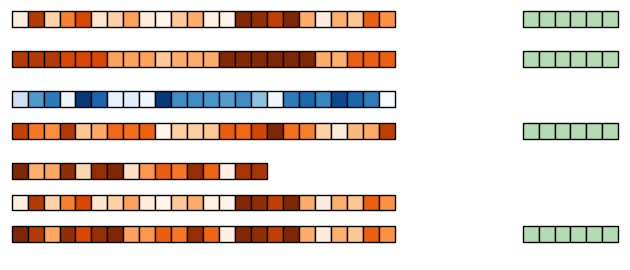

In [133]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib import cm

# 生成原始数据
# np.random.seed(8)
seq_len=24
data = np.random.rand(1, seq_len)  # 1行24列
# 对 data 进行最大最小归一化
data = (data - data.min()) / (data.max() - data.min())


# max pooling，kernel=3, stride=1, padding=1
def max_pool1d_with_padding(arr, kernel_size=3, stride=1, padding=1):
    batch, length = arr.shape
    padded = np.pad(arr, ((0, 0), (padding, padding)), mode='constant', constant_values=0)
    pooled = np.zeros_like(arr)
    for i in range(length):
        window = padded[:, i:i+kernel_size]
        pooled[:, i] = np.max(window, axis=1)
    return pooled

# 依次做两次 pooling
pooled1 = max_pool1d_with_padding(data, kernel_size=3, stride=1, padding=1)

# 合并为三行，第一行为原始数据，第二行为第一次pooling，第三行为冗余得分（新随机生成）
redundancy_score = np.random.rand(1, seq_len)  # 新随机生成一行冗余得分
all_data = np.concatenate([data, pooled1], axis=0)

fig, ax = plt.subplots()

# 归一化数据到0-1
norm = plt.Normalize(all_data.min(), all_data.max())
cmap = cm.get_cmap('Oranges')
# 新增一个冷色调
cmap_cool = cm.get_cmap('Blues')

final_score = all_data[1, :] - redundancy_score[0, :]
# 最大最小归一化
final_score = (final_score - final_score.min()) / (final_score.max() - final_score.min())
final_score=final_score.reshape(1,-1)
# 修正：确保第一行（data）也有颜色和边框

pre_score=np.random.rand(1,seq_len)
pre_score = (pre_score - pre_score.min()) / (pre_score.max() - pre_score.min())
pre_score=pre_score.reshape(1,-1)

row_gap = 1  # 行间隔
gaps=[1.5,1.5,1,1.5,1,1]
num_with_pre=16
for i in range(8):
    for j in range(all_data.shape[1]):
        if i<2:
            color = cmap(norm(all_data[i, j]))
            # y坐标加上行间隔
            rect = Rectangle((j, -i - sum(gaps[:i])), 1, 1, facecolor=color, edgecolor='black', linewidth=1)
            ax.add_patch(rect)
        elif i==2:
            color = cmap_cool(norm(redundancy_score[0, j]))
            rect = Rectangle((j, -i - sum(gaps[:i])), 1, 1, facecolor=color, edgecolor='black', linewidth=1)
            ax.add_patch(rect)
        elif i==3:
            color = cmap(norm(final_score[0, j]))
            rect = Rectangle((j, -i - sum(gaps[:i])), 1, 1, facecolor=color, edgecolor='black', linewidth=1)
            ax.add_patch(rect)
        elif i==5:
            color = cmap(norm(all_data[0, j]))
            rect = Rectangle((j, -i - sum(gaps[:i])), 1, 1, facecolor=color, edgecolor='black', linewidth=1)
            ax.add_patch(rect)
        elif i==4:
            if j>=num_with_pre:
                break
            color = cmap(norm(pre_score[0, j]))
            rect = Rectangle((j, -i - sum(gaps[:i])), 1, 1, facecolor=color, edgecolor='black', linewidth=1)
            ax.add_patch(rect)
        elif i==6:
            if j<num_with_pre:
                color = cmap(norm(max(pre_score[0, j],all_data[0, j])))
            else:
                color = cmap(norm(all_data[0, j]))
            rect = Rectangle((j, -i - sum(gaps[:i])), 1, 1, facecolor=color, edgecolor='black', linewidth=1)
            ax.add_patch(rect)

    # 隔一定间隔后画绿色小方块
    # 直接指定低饱和度绿色（如RGB: 180, 220, 180），不使用colormap
    interval = 8  # 每隔4个格子画一个
    num_green = 6
    low_saturation_green = (180/255, 220/255, 180/255)  # 低饱和度绿色
    if i in [0,1,3,6]:
        for j in range(all_data.shape[1]+interval, all_data.shape[1]+interval+num_green):
            color = low_saturation_green
            rect = Rectangle((j, -i - sum(gaps[:i])), 1, 1, facecolor=color, edgecolor='black', linewidth=1)
            ax.add_patch(rect)

# 设置坐标轴范围
ax.set_xlim(-0.1, all_data.shape[1]+interval+num_green+0.1)
ax.set_ylim(1-8.1-sum(gaps), 1.1)
ax.set_aspect('equal')
ax.axis('off')

# 添加每一行的标签
# row_labels = ['Attention Score Only', 'w/ Max Pooling', 'w/ Max Pooling & Redundancy']
# for i, label in enumerate(row_labels):
#     ax.text(-0.5, -i+0.5, label, va='center', ha='right', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig("pdf/figure.svg", format="svg")
plt.show()

# 解释：
# 第一行没有边框和颜色通常是因为没有为其绘制Rectangle对象。此处已确保所有行（包括data）都绘制了带边框和颜色的格子。